# Grokking Training Replication
Standalone training notebook for replicating results from
*"Progress Measures for Grokking via Mechanistic Interpretability"* (Nanda et al., ICLR 2023).

Extracted from the original codebase with minimal modifications (fixed relative imports, optional wandb).

In [1]:
import numpy as np
import torch
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import einops
import random
import time
import os
from pathlib import Path
from dataclasses import dataclass
import dataclasses
from collections import defaultdict
from functools import partial

import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import pandas as pd

try:
    import wandb
    HAS_WANDB = True
except ImportError:
    HAS_WANDB = False
    print("wandb not installed, training will proceed without logging")

USE_WANDB = False  # Set to True to enable wandb logging

## Helper Functions
Minimal set from `helpers.py` needed for training and metrics.

In [2]:
root = Path('saved_runs')

def cross_entropy_high_precision(logits, labels):
    # Shapes: batch x vocab, batch
    # Cast logits to float64 because log_softmax has a float32 underflow on overly
    # confident data and can only return multiples of 1.2e-7 (the smallest float x
    # such that 1+x is different from 1 in float32). This leads to loss spikes
    # and dodgy gradients
    logprobs = F.log_softmax(logits.to(torch.float64), dim=-1)
    prediction_logprobs = torch.gather(logprobs, index=labels[:, None], dim=-1)
    loss = -torch.mean(prediction_logprobs)
    return loss

def to_numpy(tensor, flat=False):
    if type(tensor) != torch.Tensor:
        return tensor
    if flat:
        return tensor.flatten().detach().cpu().numpy()
    else:
        return tensor.detach().cpu().numpy()

def unflatten_first(tensor, p):
    if tensor.shape[0] == p * p:
        return einops.rearrange(tensor, '(x y) ... -> x y ...', x=p, y=p)
    else:
        return tensor

def test_logits(logits, p, is_train, is_test, labels, bias_correction=False, original_logits=None, mode='all'):
    # Calculates cross entropy loss of logits representing a batch of all p^2
    # possible inputs
    # Batch dimension is assumed to be first
    if logits.shape[1] == p * p:
        logits = logits.T
    if logits.shape == torch.Size([p * p, p + 1]):
        logits = logits[:, :-1]
    logits = logits.reshape(p * p, p)
    if bias_correction:
        # Applies bias correction - we correct for any missing bias terms,
        # independent of the input, by centering the new logits along the batch
        # dimension, and then adding the average original logits across all inputs
        logits = einops.reduce(original_logits - logits, 'batch ... -> ...', 'mean') + logits
    if mode == 'train':
        return cross_entropy_high_precision(logits[is_train], labels[is_train])
    elif mode == 'test':
        return cross_entropy_high_precision(logits[is_test], labels[is_test])
    elif mode == 'all':
        return cross_entropy_high_precision(logits, labels)

def fft1d(tensor, fourier_basis):
    # Converts a tensor with dimension p into the Fourier basis
    return tensor @ fourier_basis.T

def fourier_2d_basis_term(x_index, y_index, fourier_basis):
    # Returns the 2D Fourier basis term corresponding to the outer product of
    # the x_index th component in the x direction and y_index th component in the
    # y direction. Returns a 1D vector of length p^2
    return (fourier_basis[x_index][:, None] * fourier_basis[y_index][None, :]).flatten()

def fft2d(mat, p, fourier_basis):
    # Converts a pxpx... or batch x ... tensor into the 2D Fourier basis.
    # Output has the same shape as the original
    shape = mat.shape
    mat = einops.rearrange(mat, '(x y) ... -> x y (...)', x=p, y=p)
    fourier_mat = torch.einsum('xyz,fx,Fy->fFz', mat, fourier_basis, fourier_basis)
    return fourier_mat.reshape(shape)

def get_component_cos_xpy(tensor, freq, fourier_basis, collapse_dim=False):
    # Gets the component corresponding to cos(freq*(x+y)) in the 2D Fourier basis
    cosx_cosy_direction = fourier_2d_basis_term(2 * freq - 1, 2 * freq - 1, fourier_basis=fourier_basis).flatten()
    sinx_siny_direction = fourier_2d_basis_term(2 * freq, 2 * freq, fourier_basis=fourier_basis).flatten()
    # Divide by sqrt(2) to ensure it remains normalised
    cos_xpy_direction = (cosx_cosy_direction - sinx_siny_direction) / np.sqrt(2)
    if collapse_dim:
        return (cos_xpy_direction @ tensor)
    else:
        return cos_xpy_direction[:, None] @ (cos_xpy_direction[None, :] @ tensor)

def get_component_sin_xpy(tensor, freq, fourier_basis, collapse_dim=False):
    # Gets the component corresponding to sin((x+y)*freq*2pi/p) in the 2D Fourier basis
    sinx_cosy_direction = fourier_2d_basis_term(2 * freq, 2 * freq - 1, fourier_basis=fourier_basis).flatten()
    cosx_siny_direction = fourier_2d_basis_term(2 * freq - 1, 2 * freq, fourier_basis=fourier_basis).flatten()
    sin_xpy_direction = (sinx_cosy_direction + cosx_siny_direction) / np.sqrt(2)
    if collapse_dim:
        return (sin_xpy_direction @ tensor)
    else:
        return sin_xpy_direction[:, None] @ (sin_xpy_direction[None, :] @ tensor)

def extract_freq_2d(tensor, freq, p):
    # Takes in a pxpx... or batch x ... tensor, returns a 3x3x... tensor of the
    # Linear and quadratic terms of frequency freq
    tensor = unflatten_first(tensor, p)
    index_1d = [0, 2 * freq - 1, 2 * freq]
    return tensor[[[i] * 3 for i in index_1d], [index_1d] * 3]

def lines(lines_list, x=None, mode='lines', labels=None, xaxis='', yaxis='', title='', log_y=False, hover=None, **kwargs):
    if type(lines_list) == torch.Tensor:
        lines_list = [lines_list[i] for i in range(lines_list.shape[0])]
    if x is None:
        x = np.arange(len(lines_list[0]))
    fig = go.Figure(layout={'title': title})
    fig.update_xaxes(title=xaxis)
    fig.update_yaxes(title=yaxis)
    for c, ln in enumerate(lines_list):
        if type(ln) == torch.Tensor:
            ln = to_numpy(ln)
        if labels is not None:
            label = labels[c]
        else:
            label = c
        fig.add_trace(go.Scatter(x=x, y=ln, mode=mode, name=label, hovertext=hover, **kwargs))
    if log_y:
        fig.update_layout(yaxis_type="log")
    fig.show()

## Model Architecture
From `transformers.py` — 1-layer transformer with HookPoints for activation caching.

In [3]:
class HookPoint(nn.Module):
    '''A helper class to get access to intermediate activations (inspired by Garcon)
    It's a dummy module that is the identity function by default
    I can wrap any intermediate activation in a HookPoint and get a convenient way to add PyTorch hooks
    '''
    def __init__(self):
        super().__init__()
        self.fwd_hooks = []
        self.bwd_hooks = []

    def give_name(self, name):
        self.name = name

    def add_hook(self, hook, dir='fwd'):
        def full_hook(module, module_input, module_output):
            return hook(module_output, name=self.name)
        if dir == 'fwd':
            handle = self.register_forward_hook(full_hook)
            self.fwd_hooks.append(handle)
        elif dir == 'bwd':
            handle = self.register_backward_hook(full_hook)
            self.bwd_hooks.append(handle)
        else:
            raise ValueError(f"Invalid direction {dir}")

    def remove_hooks(self, dir='fwd'):
        if (dir == 'fwd') or (dir == 'both'):
            for hook in self.fwd_hooks:
                hook.remove()
            self.fwd_hooks = []
        if (dir == 'bwd') or (dir == 'both'):
            for hook in self.bwd_hooks:
                hook.remove()
            self.bwd_hooks = []
        if dir not in ['fwd', 'bwd', 'both']:
            raise ValueError(f"Invalid direction {dir}")

    def forward(self, x):
        return x


class Embed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_E = nn.Parameter(t.randn(d_model, d_vocab) / np.sqrt(d_model))

    def forward(self, x):
        return t.einsum('dbp -> bpd', self.W_E[:, x])


class Unembed(nn.Module):
    def __init__(self, d_vocab, d_model):
        super().__init__()
        self.W_U = nn.Parameter(t.randn(d_model, d_vocab) / np.sqrt(d_vocab))

    def forward(self, x):
        return (x @ self.W_U)


class PosEmbed(nn.Module):
    def __init__(self, max_ctx, d_model):
        super().__init__()
        self.W_pos = nn.Parameter(t.randn(max_ctx, d_model) / np.sqrt(d_model))

    def forward(self, x):
        return x + self.W_pos[:x.shape[-2]]


class LayerNorm(nn.Module):
    def __init__(self, d_model, epsilon=1e-4, model=[None]):
        super().__init__()
        self.model = model
        self.w_ln = nn.Parameter(t.ones(d_model))
        self.b_ln = nn.Parameter(t.zeros(d_model))
        self.epsilon = epsilon

    def forward(self, x):
        if self.model[0].use_ln:
            x = x - x.mean(axis=-1)[..., None]
            x = x / (x.std(axis=-1)[..., None] + self.epsilon)
            x = x * self.w_ln
            x = x + self.b_ln
            return x
        else:
            return x


class Attention(nn.Module):
    def __init__(self, d_model, num_heads, d_head, n_ctx, model):
        super().__init__()
        self.model = model
        self.W_K = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_Q = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_V = nn.Parameter(t.randn(num_heads, d_head, d_model) / np.sqrt(d_model))
        self.W_O = nn.Parameter(t.randn(d_model, d_head * num_heads) / np.sqrt(d_model))
        self.register_buffer('mask', t.tril(t.ones((n_ctx, n_ctx))))
        self.d_head = d_head
        self.hook_k = HookPoint()
        self.hook_q = HookPoint()
        self.hook_v = HookPoint()
        self.hook_z = HookPoint()
        self.hook_attn = HookPoint()
        self.hook_attn_pre = HookPoint()

    def forward(self, x):
        k = self.hook_k(t.einsum('ihd,bpd->biph', self.W_K, x))
        q = self.hook_q(t.einsum('ihd,bpd->biph', self.W_Q, x))
        v = self.hook_v(t.einsum('ihd,bpd->biph', self.W_V, x))
        attn_scores_pre = t.einsum('biph,biqh->biqp', k, q)
        attn_scores_masked = t.tril(attn_scores_pre) - 1e10 * (1 - self.mask[:x.shape[-2], :x.shape[-2]])
        attn_matrix = self.hook_attn(F.softmax(self.hook_attn_pre(attn_scores_masked / np.sqrt(self.d_head)), dim=-1))
        z = self.hook_z(t.einsum('biph,biqp->biqh', v, attn_matrix))
        z_flat = einops.rearrange(z, 'b i q h -> b q (i h)')
        out = t.einsum('df,bqf->bqd', self.W_O, z_flat)
        return out


class MLP(nn.Module):
    def __init__(self, d_model, d_mlp, act_type, model):
        super().__init__()
        self.model = model
        self.W_in = nn.Parameter(t.randn(d_mlp, d_model) / np.sqrt(d_model))
        self.b_in = nn.Parameter(t.zeros(d_mlp))
        self.W_out = nn.Parameter(t.randn(d_model, d_mlp) / np.sqrt(d_model))
        self.b_out = nn.Parameter(t.zeros(d_model))
        self.act_type = act_type
        self.hook_pre = HookPoint()
        self.hook_post = HookPoint()
        assert act_type in ['ReLU', 'GeLU']

    def forward(self, x):
        x = self.hook_pre(t.einsum('md,bpd->bpm', self.W_in, x) + self.b_in)
        if self.act_type == 'ReLU':
            x = F.relu(x)
        elif self.act_type == 'GeLU':
            x = F.gelu(x)
        x = self.hook_post(x)
        x = t.einsum('dm,bpm->bpd', self.W_out, x) + self.b_out
        return x


class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_mlp, d_head, num_heads, n_ctx, act_type, model):
        super().__init__()
        self.model = model
        self.attn = Attention(d_model, num_heads, d_head, n_ctx, model=self.model)
        self.mlp = MLP(d_model, d_mlp, act_type, model=self.model)
        self.hook_attn_out = HookPoint()
        self.hook_mlp_out = HookPoint()
        self.hook_resid_pre = HookPoint()
        self.hook_resid_mid = HookPoint()
        self.hook_resid_post = HookPoint()

    def forward(self, x):
        x = self.hook_resid_mid(x + self.hook_attn_out(self.attn((self.hook_resid_pre(x)))))
        x = self.hook_resid_post(x + self.hook_mlp_out(self.mlp((x))))
        return x


class Transformer(nn.Module):
    def __init__(self, config, use_cache=False, use_ln=True):
        super().__init__()
        self.cache = {}
        self.use_cache = use_cache
        self.embed = Embed(d_vocab=config.d_vocab, d_model=config.d_model)
        self.pos_embed = PosEmbed(max_ctx=config.n_ctx, d_model=config.d_model)
        self.blocks = nn.ModuleList([TransformerBlock(
            d_model=config.d_model,
            d_mlp=config.d_mlp,
            d_head=config.d_head,
            num_heads=config.num_heads,
            n_ctx=config.n_ctx,
            act_type=config.act_type,
            model=[self]) for i in range(config.num_layers)])
        self.unembed = Unembed(d_vocab=config.d_vocab, d_model=config.d_model)
        self.use_ln = use_ln

        for name, module in self.named_modules():
            if type(module) == HookPoint:
                module.give_name(name)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos_embed(x)
        for block in self.blocks:
            x = block(x)
        x = self.unembed(x)
        return x

    def set_use_cache(self, use_cache):
        self.use_cache = use_cache

    def hook_points(self):
        return [module for name, module in self.named_modules() if 'hook' in name]

    def remove_all_hooks(self):
        for hp in self.hook_points():
            hp.remove_hooks('fwd')
            hp.remove_hooks('bwd')

    def cache_all(self, cache, incl_bwd=False):
        def save_hook(tensor, name):
            cache[name] = tensor.detach()
        def save_hook_back(tensor, name):
            cache[name + '_grad'] = tensor[0].detach()
        for hp in self.hook_points():
            hp.add_hook(save_hook, 'fwd')
            if incl_bwd:
                hp.add_hook(save_hook_back, 'bwd')

## Config, Metrics & Data Generation

In [4]:
@dataclass(frozen=True)
class Config():
    lr: float = 1e-3
    weight_decay: float = 1.0
    p: int = 113
    d_model: int = 128
    fn_name: str = 'add'
    frac_train: float = 0.3
    num_epochs: int = 50000
    save_models: bool = False
    save_every: int = 100
    stopping_thresh: int = -1
    seed: int = 0

    num_layers: int = 1
    batch_style: str = 'full'
    d_vocab: int = p + 1
    n_ctx: int = 3
    d_mlp: int = 4 * d_model
    num_heads: int = 4

    act_type: str = 'ReLU'

    device: t.device = t.device("cuda" if t.cuda.is_available() else "cpu" if t.backends.mps.is_available() else "cpu")

    use_ln: bool = False

    take_metrics_every_n_epochs: int = 1000

    @property
    def d_head(self):
        return self.d_model // self.num_heads

    @property
    def random_answers(self):
        return np.random.randint(low=0, high=self.p, size=(self.p, self.p))

    @property
    def fns_dict(self):
        return {
            'add': lambda x, y: (x + y) % self.p,
            'subtract': lambda x, y: (x - y) % self.p,
            'x2xyy2': lambda x, y: (x**2 + x * y + y**2) % self.p,
            'rand': lambda x, y: self.random_answers[x][y]
        }

    @property
    def fn(self):
        return self.fns_dict[self.fn_name]

    def is_train_is_test(self, train):
        is_train = []
        is_test = []
        for x in range(self.p):
            for y in range(self.p):
                if (x, y, 113) in train:
                    is_train.append(True)
                    is_test.append(False)
                else:
                    is_train.append(False)
                    is_test.append(True)
        is_train = np.array(is_train)
        is_test = np.array(is_test)
        return (is_train, is_test)

    def is_it_time_to_save(self, epoch):
        return (epoch % self.save_every == 0)

    def is_it_time_to_take_metrics(self, epoch):
        return epoch % self.take_metrics_every_n_epochs == 0

assert Config.d_model % Config.num_heads == 0

In [5]:
def make_fourier_basis(config):
    fourier_basis = []
    fourier_basis.append(t.ones(config.p) / np.sqrt(config.p))
    for i in range(1, config.p // 2 + 1):
        fourier_basis.append(t.cos(2 * t.pi * t.arange(config.p) * i / config.p))
        fourier_basis.append(t.sin(2 * t.pi * t.arange(config.p) * i / config.p))
        fourier_basis[-2] /= fourier_basis[-2].norm()
        fourier_basis[-1] /= fourier_basis[-1].norm()
    return t.stack(fourier_basis, dim=0).to(config.device)


def calculate_key_freqs(config, model, all_data):
    labels = t.tensor([config.fn(i, j) for i, j, _ in all_data]).to(config.device)
    cache = {}
    model.remove_all_hooks()
    model.cache_all(cache)
    model(all_data)
    neuron_acts = cache['blocks.0.mlp.hook_post'][:, -1]
    neuron_acts_centered = neuron_acts - einops.reduce(neuron_acts, 'batch neuron -> 1 neuron', 'mean')
    fourier_basis = make_fourier_basis(config=config)
    fourier_neuron_acts = fft2d(neuron_acts_centered, p=config.p, fourier_basis=fourier_basis)

    fourier_neuron_acts_square = fourier_neuron_acts.reshape(config.p, config.p, config.d_mlp)
    neuron_freqs = []
    neuron_frac_explained = []
    for ni in range(config.d_mlp):
        best_frac_explained = -1e6
        best_freq = -1
        for freq in range(1, config.p // 2):
            numerator = extract_freq_2d(fourier_neuron_acts_square[:, :, ni], freq, p=config.p).pow(2).sum()
            denominator = fourier_neuron_acts_square[:, :, ni].pow(2).sum().item()
            frac_explained = numerator / denominator
            if frac_explained > best_frac_explained:
                best_freq = freq
                best_frac_explained = frac_explained
        neuron_freqs.append(best_freq)
        neuron_frac_explained.append(best_frac_explained)
    neuron_freqs = np.array(neuron_freqs)
    neuron_frac_explained = to_numpy(neuron_frac_explained)
    key_freqs, neuron_freq_counts = np.unique(neuron_freqs, return_counts=True)
    return key_freqs


def get_components_of_trig_loss(logits, freq, fourier_basis):
    cos = get_component_cos_xpy(logits, freq, fourier_basis=fourier_basis)
    sin = get_component_sin_xpy(logits, freq, fourier_basis=fourier_basis)
    return cos + sin


def calculate_excluded_loss(config, fourier_basis, key_freqs, is_train, is_test, labels, logits):
    row = []
    for freq in key_freqs:
        cos = get_component_cos_xpy(logits, freq, fourier_basis=fourier_basis)
        sin = get_component_sin_xpy(logits, freq, fourier_basis=fourier_basis)
        value = test_logits(logits - cos - sin, bias_correction=False, mode='train', p=config.p,
                            is_train=is_train, is_test=is_test, labels=labels)
        row.append(value.item())
    return row


def calculate_trig_loss(config, model, train, logits, key_freqs, fourier_basis, all_data, is_train, is_test, labels, mode='all'):
    trig_logits = sum([get_components_of_trig_loss(logits, freq, fourier_basis) for freq in key_freqs])
    return test_logits(trig_logits,
                       p=config.p,
                       is_train=is_train,
                       is_test=is_test,
                       labels=labels,
                       bias_correction=True,
                       original_logits=logits,
                       mode=mode)


def calculate_coefficients(logits, fourier_basis, key_freqs, p, device):
    x = t.arange(p)[None, :, None, None]
    y = t.arange(p)[None, None, :, None]
    z = t.arange(p)[None, None, None, :]
    w = t.arange(1, (p // 2 + 1))[:, None, None, None]
    coses = t.cos(w * t.pi * 2 / p * (x + y - z)).to(device)
    coses = coses.reshape(p // 2, p * p, p)
    coses /= coses.pow(2).sum([-2, -1], keepdim=True).sqrt()
    cos_coefficients = (coses * logits).sum([-2, -1])
    return cos_coefficients

In [6]:
def gen_train_test(config):
    '''Generate train and test split'''
    num_to_generate = config.p
    pairs = [(i, j, num_to_generate) for i in range(num_to_generate) for j in range(num_to_generate)]
    random.seed(config.seed)
    random.shuffle(pairs)
    div = int(config.frac_train * len(pairs))
    return pairs[:div], pairs[div:]


def full_loss(config, model, data):
    '''Takes the cross entropy loss of the model on the data'''
    # Take the final position only
    logits = model(data)[:, -1]
    labels = t.tensor([config.fn(i, j) for i, j, _ in data]).to(config.device)
    return cross_entropy_high_precision(logits, labels)

## Trainer
Full training loop with checkpoint saving and metric computation.

In [7]:
class Trainer:
    def __init__(self, config, model=None):
        if USE_WANDB and HAS_WANDB:
            wandb.init(project="grokking", config=dataclasses.asdict(config))
        self.model = model if model is not None else Transformer(config, use_cache=False)
        self.model.to(config.device)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=config.lr, weight_decay=config.weight_decay, betas=(0.9, 0.98))
        self.scheduler = optim.lr_scheduler.LambdaLR(self.optimizer, lambda step: min(step / 10, 1))
        self.run_name = f"grok_{int(time.time())}"
        self.train, self.test = gen_train_test(config=config)
        self.metrics_dictionary = defaultdict(dict)
        print('training length = ', len(self.train))
        print('testing length = ', len(self.test))
        self.train_losses = []
        self.test_losses = []
        self.config = config

    def save_epoch(self, epoch, save_to_wandb=True):
        save_dict = {
            'model': self.model.state_dict(),
            'train_loss': self.train_losses[-1],
            'test_loss': self.test_losses[-1],
            'epoch': epoch,
        }
        if save_to_wandb and USE_WANDB and HAS_WANDB:
            wandb.log(save_dict)
            print("Saved epoch to wandb")
        if self.config.save_models:
            t.save(save_dict, root / self.run_name / f"{epoch}.pth")
            print(f"Saved model to {root / self.run_name / f'{epoch}.pth'}")
        self.metrics_dictionary[epoch].update(save_dict)

    def do_a_training_step(self, epoch):
        '''returns train_loss, test_loss'''
        train_loss = full_loss(config=self.config, model=self.model, data=self.train)
        test_loss = full_loss(config=self.config, model=self.model, data=self.test)
        self.train_losses.append(train_loss.item())
        self.test_losses.append(test_loss.item())
        if epoch % 100 == 0:
            print(f'Epoch {epoch}, train loss {t.log(train_loss).item():.4f}, test loss {t.log(test_loss).item():.4f}')
        train_loss.backward()
        self.optimizer.step()
        self.scheduler.step()
        self.optimizer.zero_grad()
        return train_loss, test_loss

    def initial_save_if_appropriate(self):
        if self.config.save_models:
            os.mkdir(root / self.run_name)
            save_dict = {
                'model': self.model.state_dict(),
                'train_data': self.train,
                'test_data': self.test}
            t.save(save_dict, root / self.run_name / 'init.pth')

    def post_training_save(self, save_optimizer_and_scheduler=True, log_to_wandb=True):
        if not self.config.save_models:
            os.makedirs(root / self.run_name, exist_ok=True)
        save_dict = {
            'model': self.model.state_dict(),
            'train_loss': self.train_losses[-1],
            'test_loss': self.test_losses[-1],
            'train_losses': self.train_losses,
            'test_losses': self.test_losses,
            'epoch': self.config.num_epochs,
        }
        if save_optimizer_and_scheduler:
            save_dict['optimizer'] = self.optimizer.state_dict()
            save_dict['scheduler'] = self.scheduler.state_dict()
        if log_to_wandb and USE_WANDB and HAS_WANDB:
            wandb.log(save_dict)
        t.save(save_dict, root / self.run_name / f"final.pth")
        print(f"Saved model to {root / self.run_name / f'final.pth'}")
        self.metrics_dictionary[save_dict['epoch']].update(save_dict)

    def take_metrics(self, train, epoch):
        with t.inference_mode():
            def sum_sq_weights():
                row = []
                for name, param in self.model.named_parameters():
                    row.append(param.pow(2).sum().item())
                return row

            print('taking metrics')

            all_data = t.tensor([(i, j, self.config.p) for i in range(self.config.p) for j in range(self.config.p)]).to(self.config.device)
            key_freqs = calculate_key_freqs(config=self.config, model=self.model, all_data=all_data)
            logits = self.model(all_data)[:, -1, :-1]
            fourier_basis = make_fourier_basis(config=self.config)
            is_train, is_test = self.config.is_train_is_test(train=train)
            labels = t.tensor([self.config.fn(i, j) for i, j, _ in all_data]).to(self.config.device)

            metrics = {
                'epoch': epoch,
                'trig_loss': calculate_trig_loss(
                    config=self.config,
                    model=self.model,
                    train=train,
                    key_freqs=key_freqs,
                    is_test=is_test,
                    is_train=is_train,
                    labels=labels,
                    logits=logits,
                    fourier_basis=fourier_basis,
                    all_data=all_data),
                'sum_of_squared_weights': sum_sq_weights(),
                'excluded_loss': calculate_excluded_loss(
                    logits=logits,
                    key_freqs=key_freqs,
                    fourier_basis=fourier_basis,
                    is_train=is_train,
                    config=self.config,
                    is_test=is_test,
                    labels=labels),
                'coefficients': calculate_coefficients(
                    p=self.config.p,
                    logits=logits,
                    fourier_basis=fourier_basis,
                    key_freqs=key_freqs,
                    device=self.config.device),
            }
            if USE_WANDB and HAS_WANDB:
                wandb.log(metrics)
                print("Logged metrics to wandb")
            self.metrics_dictionary[epoch].update(metrics)


def train_model(config):
    t.manual_seed(config.seed)
    np.random.seed(config.seed)
    random.seed(config.seed)
    if t.cuda.is_available():
        t.cuda.manual_seed_all(config.seed)

    world = Trainer(config=config)
    print(f'Run name {world.run_name}')
    world.initial_save_if_appropriate()

    for epoch in range(config.num_epochs):
        train_loss, test_loss = world.do_a_training_step(epoch)
        if test_loss.item() < config.stopping_thresh:
            break
        if config.is_it_time_to_save(epoch=epoch):
            world.save_epoch(epoch=epoch)
        if config.is_it_time_to_take_metrics(epoch=epoch):
            world.take_metrics(epoch=epoch, train=world.train)

    world.post_training_save(save_optimizer_and_scheduler=True)
    lines([world.train_losses, world.test_losses], labels=['train', 'test'], log_y=True)
    return world

## Run Training
Default config matches paper: `p=113`, `lr=1e-3`, `weight_decay=1.0`, `d_model=128`, 4 heads, 512 MLP, ReLU, 50k epochs.
Set `save_models=True` to save per-epoch checkpoints.

In [8]:
config = Config(
    save_models=True,   # Save state dicts every save_every epochs
    save_every=100,     # Checkpoint every 100 epochs (paper uses this)
    num_epochs=40000,   # Full training run
)
print(f"Training on: {config.device}")
print(f"p={config.p}, d_model={config.d_model}, d_mlp={config.d_mlp}, num_heads={config.num_heads}")
print(f"lr={config.lr}, weight_decay={config.weight_decay}, frac_train={config.frac_train}")
print(f"num_epochs={config.num_epochs}, save_every={config.save_every}")
print(f"Metrics every {config.take_metrics_every_n_epochs} epochs")
print(f"Checkpoints will save to: saved_runs/grok_<timestamp>/")

Training on: cpu
p=113, d_model=128, d_mlp=512, num_heads=4
lr=0.001, weight_decay=1.0, frac_train=0.3
num_epochs=40000, save_every=100
Metrics every 1000 epochs
Checkpoints will save to: saved_runs/grok_<timestamp>/


training length =  3830
testing length =  8939
Run name grok_1778981592
Epoch 0, train loss 1.5611, test loss 1.5620
Saved model to saved_runs/grok_1778981592/0.pth
taking metrics
Epoch 100, train loss 0.8209, test loss 2.0456
Saved model to saved_runs/grok_1778981592/100.pth
Epoch 200, train loss -3.9022, test loss 2.7760
Saved model to saved_runs/grok_1778981592/200.pth
Epoch 300, train loss -4.9334, test loss 2.8005
Saved model to saved_runs/grok_1778981592/300.pth
Epoch 400, train loss -6.0575, test loss 2.8545
Saved model to saved_runs/grok_1778981592/400.pth
Epoch 500, train loss -7.1591, test loss 2.9108
Saved model to saved_runs/grok_1778981592/500.pth
Epoch 600, train loss -8.2433, test loss 2.9668
Saved model to saved_runs/grok_1778981592/600.pth
Epoch 700, train loss -9.3149, test loss 3.0208
Saved model to saved_runs/grok_1778981592/700.pth
Epoch 800, train loss -10.3702, test loss 3.0728
Saved model to saved_runs/grok_1778981592/800.pth
Epoch 900, train loss -11.3999, test

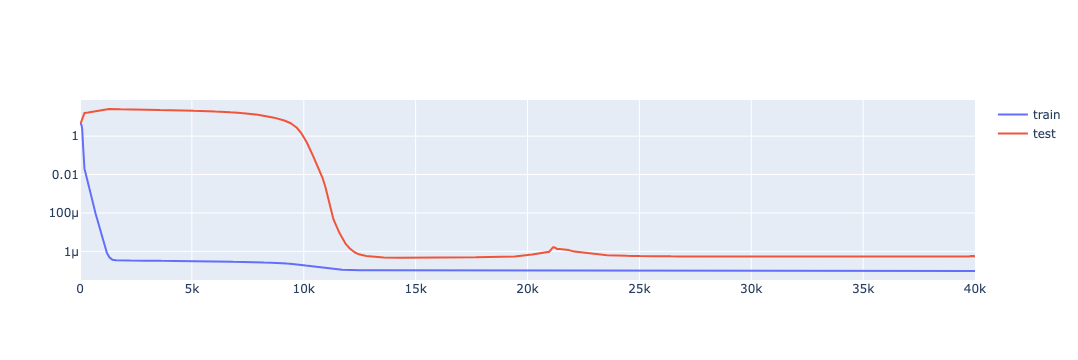

In [9]:
world = train_model(config)

## Inspect Results

In [10]:
print(f"Final train loss: {world.train_losses[-1]:.6f}")
print(f"Final test loss: {world.test_losses[-1]:.6f}")
print(f"Metrics collected at epochs: {sorted(world.metrics_dictionary.keys())}")

Final train loss: 0.000000
Final test loss: 0.000001
Metrics collected at epochs: [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 